#### 1. Load a dataset

In [1]:
import pandas as pd
import numpy as np
import visualize_scores as visualize

scores = pd.read_csv("scores_all.csv")

In [2]:
scores.head(10)

,Prompt,Assignment,EssayType,Writer,Grader,Issues,Evidence,Context,Position,Conclusions,Total,HasZero,Issues_zero,Evidence_zero,Context_zero,Position_zero,Conclusions_zero
0,p0,A1,generate,chatgpt,claude,4.0,4.0,4.0,4.0,4.0,20.0,False,False,False,False,False,False
1,p0,A1,generate,chatgpt,gemini,4.0,4.0,4.0,4.0,4.0,20.0,False,False,False,False,False,False
2,p0,A1,generate,chatgpt,grok,4.0,4.0,4.0,4.0,4.0,20.0,False,False,False,False,False,False
3,p0,A1,generate,claude,chatgpt,4.0,3.0,3.0,3.0,3.0,16.0,False,False,False,False,False,False
4,p0,A1,generate,claude,gemini,4.0,4.0,4.0,4.0,4.0,20.0,False,False,False,False,False,False
5,p0,A1,generate,claude,grok,4.0,4.0,3.0,4.0,4.0,19.0,False,False,False,False,False,False
6,p0,A1,generate,gemini,chatgpt,4.0,4.0,3.0,4.0,4.0,19.0,False,False,False,False,False,False
7,p0,A1,generate,gemini,claude,4.0,4.0,4.0,4.0,4.0,20.0,False,False,False,False,False,False
8,p0,A1,generate,gemini,grok,4.0,4.0,4.0,4.0,4.0,20.0,False,False,False,False,False,False
9,p0,A1,generate,grok,chatgpt,3.0,3.0,2.0,3.0,3.0,14.0,False,False,False,False,False,False


#### 2. Check len for each row

In [3]:
prompts = ['p0', 'p1', 'p2', 'p3', 'p4', 'p5', 'p6', 'p7', 'p8', 'p9', 'p10', 'p11']

for p in prompts:
    assignment = scores.loc[scores['Prompt'] == p, 'Assignment']
    print(p, len(assignment))

p0 72
p1 72
p2 72
p3 72
p4 72
p5 72
p6 72
p7 72
p8 72
p9 72
p10 69
p11 72


In [4]:
p10_generate = scores.loc[(scores['Prompt'] == 'p10') & (scores['EssayType'] == 'generate'), 'Assignment']
print(p10_generate.value_counts().sort_index())
print(len(p10_generate))

Assignment
A1    12
A2    12
A3     9
Name: count, dtype: int64
33


Once ChatGPT receives the P10 generate prompt for A3, it asks for clarification: who is them?. I regenerated this essay few times, but I received the same answer. Therefore, no essay is generated, and thus three scores files for claude, gemini, grok never created.

In [5]:
import json, os

base = "/Users/ramihuunguyen/Documents/PhD/ai-assessment"

score_files = [
    "data/critical_thinking/a3_gen_chatgpt_p10.json"
]

for path in score_files:
    with open(os.path.join(base, path)) as f:
        data = json.load(f)
    
    print(json.dumps(data, indent=2))
    print()

{
  "command": "generate",
  "model": "gpt-5.2-2025-12-11",
  "essay_name": "Assignment_3",
  "folder": "critical_thinking",
  "prompt": "Perform a real estate investment market analysis in the Boston Metropolitan Area for 2024. Summarize the key findings, insights from the analysis, highlight the best real estate investment opportunities, and any significant patterns observed.",
  "prompt_step2": "Let's think step by step. Generate a five-page essay (1000 words or less) to set them straight and include at least 5 citations from peer-reviewed articles.",
  "step1_result": "## Boston Metropolitan Area (Greater Boston) \u2014 Real Estate Investment Market Analysis (2024)\n\n### Executive snapshot (2024)\n- **Market regime:** High-rate, low-transaction environment with **stable-to-rising rents** and **modestly softening prices** in many submarkets\u2014creating **selective buying opportunities**, especially for operators who can add value or navigate regulations.\n- **Demand anchors:** Wo

#### 3.Average Total Score By Essay Type

In [6]:
techniques = [
    'Write',
    'Persona +\nWrite',
    'Persona +\nWrite Formal',
    'CoT +\nWrite',
    'Generate',
    'CoT +\nGenerate',
    'Persona +\nGenerate',
    'Iterative + Persona\n+ Generate',
    'Iterative + Persona\n+ Write',
    'Iterative +\nGenerate',
    'Iterative + CoT\n+ Generate',
    'Iterative +\nWrite'
]

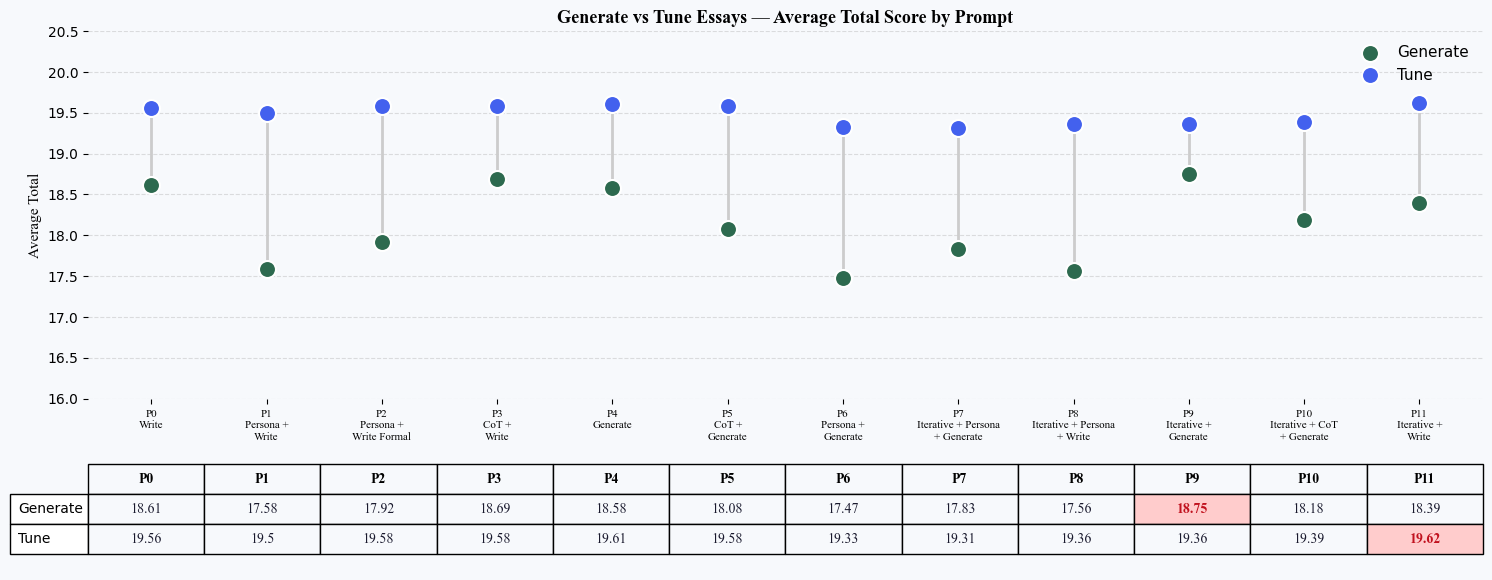

In [7]:
visualize.avg_total_score_by_essay_type(scores, prompts, techniques)

### Insights 

1. Tune essays consistently outperfrom Generate across all prompts. 
2. Best generate prompt is prompt 9 (interative + generate) at 18.75.

For higher ed journal: 

- Students do not need to know anything about AI to get an A. That is the problem.


Research Question: To what extent can undergraduate students produce high-scoring critical thinking essays using minimal AI prompting, and how do these scores compare to human expert evaluations using AAC&U VALUE rubrics?

Although prompt 9 (interative+generate) reached at 18.75 is actually strong generate score, but it contracts with my argument: is it complex prompt. 

- Look at Prompt 0 (write) at 18.61: this is the strongest case. It includes the most minimal prompt possible. 
  - Students need zero knowledge of prompting to use it. 

For computer science journal:

Research Question: 

1. Which rubric dimensions produce the greatest divergence among LLM evaluators?
2. How does prompt engineering complexity affect scores of AI-generated essays and AI-tuned essays assigned by four LLM evaluators and human expert raters using AAC&U VALUE rubrics?


#### Writer Performance Across Dimension and Assignments

##### 1. Which rubric dimensions produce the greatest divergence among LLM evaluators?

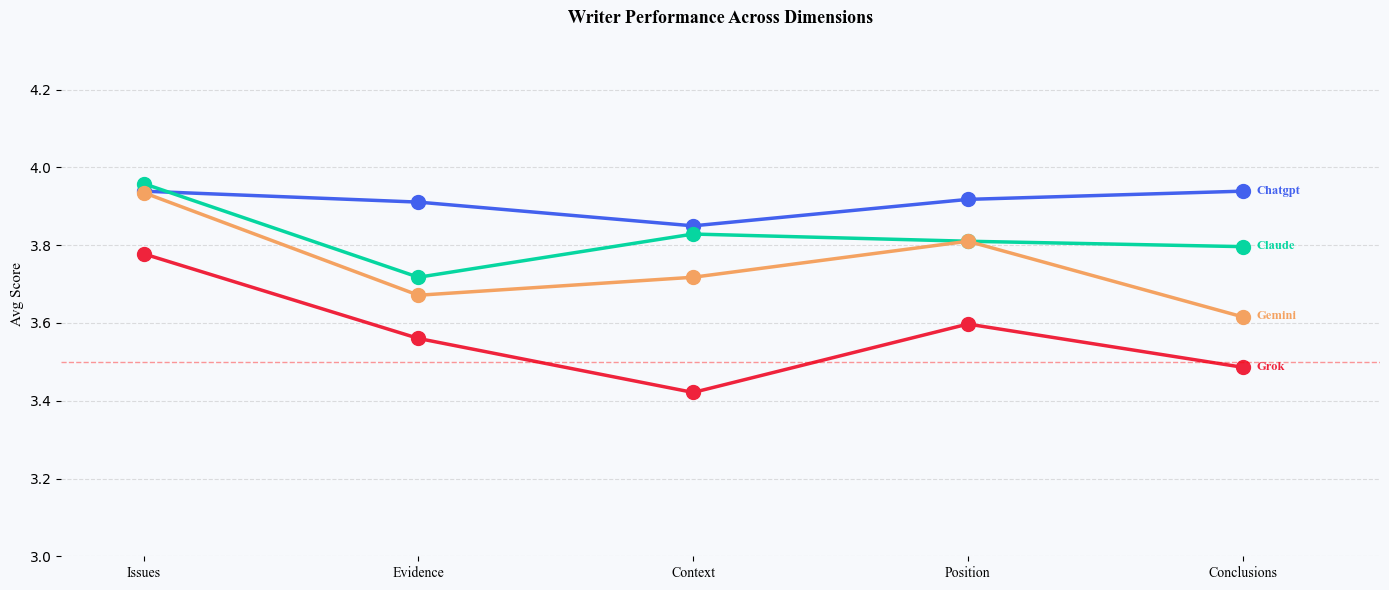

In [8]:
dimensions = ['Issues', 'Evidence', 'Context', 'Position', 'Conclusions']

writers = ['chatgpt', 'claude', 'gemini', 'grok'] 

visualize.writer_performance(scores, dimensions, writers)

Direction 1: Model Performance

- ChatGPT is the flattest, most stable line. 
- Claude is second, slightly dipping at Evidence but recovering. 
- Gemini starts strong at Issues but drops at Evidence and Conclusions. 
- Grok is the most volatile: starts at 3.78 on Issues but crashes to 3.41 at Context, the only model that falls below 3.5.

Direction 2: Dimension Analysis

- Issues: All models are strongest here. The lines are clustered near the top.
- Evidence: The gap between ChatGPT and Grok is largest here. 
- Context: ChatGPT stays high. Claude and Gemini fluctuate. Grok dips below the threshold line
- Position: Most models rebound in Position compared to Evidence and Context.
- Conclusion: ChatGPT rises again. Claude stays steady. Gemini drops more than expected. Grok hovers near the threshold.

--> Model ranking is clear — ChatGPT > Claude > Gemini > Grok.

--> Evidence and Context are the two dimensions where model differences show up most clearly.

##### 2. Which assignment results in the highest and lowest overall scores across evaluators?

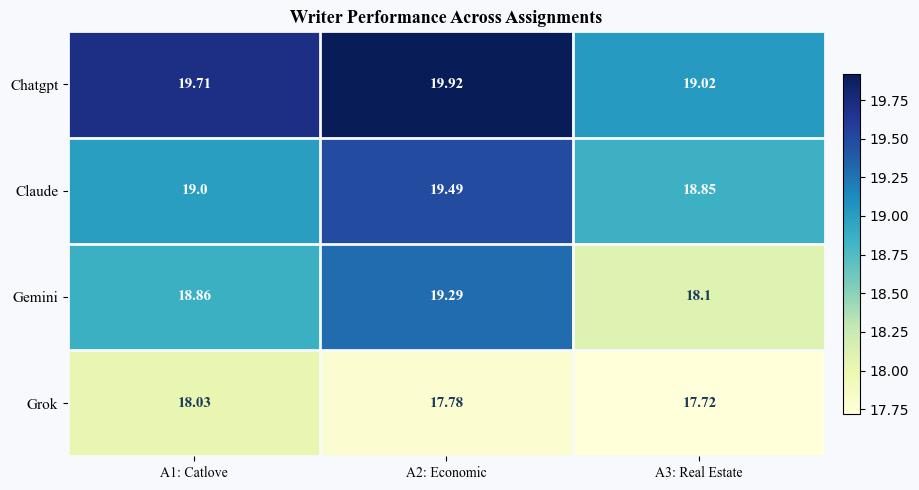

,A1: Catlove,A2: Economic,A3: Real Estate
Chatgpt,19.71,19.92,19.02
Claude,19.00,19.49,18.85
Gemini,18.86,19.29,18.10
Grok,18.03,17.78,17.72


In [9]:
df = visualize.writer_performance_by_assignment(scores, writers)
df

1. ChatGPT dominates across all assignments. Scores 19.71, 19.92, 19.02: consistently the darkest row. Even in A3 (Real Estate) drops, ChatGPT stays above 19. 
   - That’s tight clustering. High stability.

2. A2 (Economic) is the best assignment for all models. Every single model scores highest in A2. ChatGPT peaks at 19.92, Claude at 19.49, Gemini at 19.29, even Grok's best is here at 17.78. Economic reasoning appears to play to AI strengths.

3. A3 (Real Estate) is hardest for all models. Every model drops in A3: the entire right column is lighter than the middle. Gemini drops the most: from 19.29 to 18.10, a 1.19 point fall. This confirms A3 is the most domain-demanding assignment.

4. Grok is structurally separated from the rest, The bottom row is visibly lighter than the rest models across all three assignments.

##### 3.How does increasing prompt complexity influence essay scores across different LLM evaluators?

In [12]:
technique_groups = {
    'Baseline': [
        'p0'  # Baseline
    ],

    'Single': [
        'p1',  # Role-based
        'p3',  # Chain of Thought
        'p4'   # Generate Knowledge
    ],

    'Double': [
        'p2',  # Role-based + Formal
        'p5',  # Chain of Thought + Generate Knowledge
        'p6'   # Role-based + Generate Knowledge
    ],

    'Iterative_Prompt': [
        'p11', # Iterative + Original
        'p8',  # Iterative + Role-based
        'p9'   # Iterative + Generate Knowledge
    ],

    'Iterative_Prompt_Complex': [
        'p7',   # Iterative + Role-based + Generate Knowledge
        'p10'   # Iterative + Chain of Thought + Generate Knowledge
    ]
}

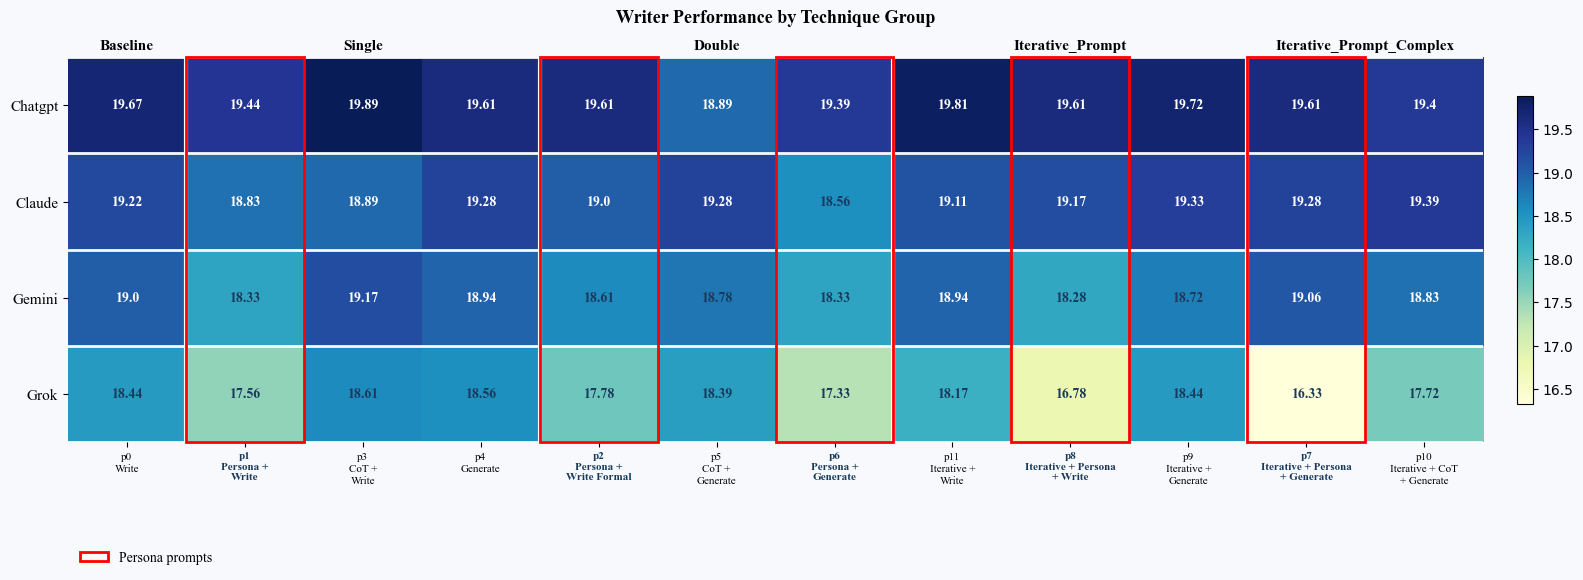

Prompt,p0,p1,p3,p4,p2,p5,p6,p11,p8,p9,p7,p10
Chatgpt,19.67,19.44,19.89,19.61,19.61,18.89,19.39,19.81,19.61,19.72,19.61,19.40
Claude,19.22,18.83,18.89,19.28,19.00,19.28,18.56,19.11,19.17,19.33,19.28,19.39
Gemini,19.00,18.33,19.17,18.94,18.61,18.78,18.33,18.94,18.28,18.72,19.06,18.83
Grok,18.44,17.56,18.61,18.56,17.78,18.39,17.33,18.17,16.78,18.44,16.33,17.72


In [11]:
df1 = visualize.writer_performance_by_technique(scores, writers, prompts, techniques, technique_groups)
df1